In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import json
import statsmodels.formula.api as smf
from src.dynamic_pricing_data_loader import cargar_y_preparar_datos
from Tools.ExtractData import GetDataFromETL

In [2]:
Data= GetDataFromETL(True)
df=Data.Frame

El archivo JSON ha sido actualizado con las nuevas rutas.
Memoria usada antes: 5191.42 MB
Memoria usada después: 986.26 MB
Reducción: 81.0%


In [3]:
sorted(list(df.columns))

['AREA_VENTA',
 'AÑO',
 'BOLETOS_CANCEL',
 'BOLETOS_TOTALES',
 'BOLETOS_VEND',
 'CAPACIDAD_ASIENTOS_TRAMO',
 'CLASE_SERVICIO',
 'CUENTA_CORRIDA',
 'CV_ASIGN',
 'CV_CORRIDA',
 'DESC_DESCUENTO',
 'DESTINO',
 'DESTINO_CORRIDA',
 'DIAS_ANTICIPACION',
 'DIF_TARIF',
 'DISPONIBILIDAD_TRAMO',
 'EFECTIVO',
 'EMAIL',
 'EMPRESA',
 'FECHA_CORRIDA',
 'FECHA_OPERACION',
 'HORAS_ANTICIPACION',
 'HORA_DECIMAL',
 'HORA_OPERACION',
 'HORA_SALIDA_CORRIDA',
 'HORA_SALIDA_CORRIDA_',
 'HORA_SALIDA_ORIGEN_CORRIDA',
 'INGRESO_TEORICO_TRAMO',
 'INGRESO_TRANSP',
 'IVA_CANCEL',
 'IVA_TARIFA_BASE_TRAMO',
 'IVA_TRANSP',
 'IVA_VENDIDO',
 'KMS_ACUM_CORRIDA',
 'KMS_TRAMO',
 'MES',
 'NOMBRE_DIA_CORRIDA',
 'NOMBRE_DIA_OPERACION',
 'NOMBRE_PASAJERO',
 'NUM_ASIENTO',
 'OCUPACION_PUNTO',
 'OCUPACION_TRAMO',
 'OPERACION',
 'ORIGEN',
 'ORIGEN_CORRIDA',
 'ORIGEN_DESTINO',
 'PAGO_METODO',
 'PAX_BAJAN',
 'PAX_SUBEN',
 'PORCENT_PROMO',
 'TARIFA_BASE_TRAMO',
 'TARJETA',
 'TIEMPO_ANTICIPACION',
 'TIPO_BUS',
 'TIPO_CLIENTE',
 'TIP

In [4]:
#Df=df[['ORIGEN_DESTINO','FECHA_CORRIDA','HORA_SALIDA_CORRIDA','CV_CORRIDA','KMS_TRAMO','CAPACIDAD_ASIENTOS_TRAMO','OCUPACION_TRAMO','INGRESO_TRANSP','TIPO_CORRIDA']].copy()

In [5]:
df['FECHA_CORRIDA']=pd.to_datetime(df['FECHA_CORRIDA'])
df['HORA_SALIDA_CORRIDA']=pd.to_datetime(df['HORA_SALIDA_CORRIDA'])
Df=df[df['FECHA_CORRIDA'].dt.year>=2025].copy()

In [44]:
Df1=Df.copy()
Df1['HORA_SALIDA_CORRIDA']=Df1['HORA_SALIDA_CORRIDA'].dt.time
Df_Horarios = Df1.groupby(['ORIGEN_DESTINO', 'FECHA_CORRIDA', 'HORA_SALIDA_CORRIDA','TIPO_CORRIDA']).agg({
    'CUENTA_CORRIDA': 'mean',
    'PAX_SUBEN': 'mean',
    'INGRESO_TRANSP':'mean'
}).reset_index().sort_values(by=['ORIGEN_DESTINO', 'FECHA_CORRIDA', 'HORA_SALIDA_CORRIDA'],ascending=[True, True, True])
#Df_2= Df_Horarios.dropna()

In [48]:
Df_Horarios[Df_Horarios['ORIGEN_DESTINO']=='ZACA-AGUA']

,ORIGEN_DESTINO,FECHA_CORRIDA,HORA_SALIDA_CORRIDA,TIPO_CORRIDA,CUENTA_CORRIDA,PAX_SUBEN,INGRESO_TRANSP
2398032,ZACA-AGUA,2025-01-01,00:00:00,EXTRA,NaN,NaN,NaN
2398033,ZACA-AGUA,2025-01-01,00:00:00,NORMAL,NaN,NaN,NaN
2398034,ZACA-AGUA,2025-01-01,00:14:00,EXTRA,NaN,NaN,NaN
2398035,ZACA-AGUA,2025-01-01,00:14:00,NORMAL,NaN,NaN,NaN
2398036,ZACA-AGUA,2025-01-01,00:14:01,EXTRA,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2697781,ZACA-AGUA,2026-03-03,23:58:01,NORMAL,NaN,NaN,NaN
2697782,ZACA-AGUA,2026-03-03,23:59:00,EXTRA,NaN,NaN,NaN
2697783,ZACA-AGUA,2026-03-03,23:59:00,NORMAL,NaN,NaN,NaN
2697784,ZACA-AGUA,2026-03-03,23:59:01,EXTRA,NaN,NaN,NaN


In [ ]:
Df_1= Df.groupby(['ORIGEN_DESTINO','FECHA_CORRIDA','HORA_SALIDA_CORRIDA','CV_CORRIDA'],observed=True).agg({
    'KMS_TRAMO':'mean',
    'CAPACIDAD_ASIENTOS_TRAMO':'mean',
    'OCUPACION_TRAMO':'mean',
    'INGRESO_TRANSP':'mean'
}).reset_index()
#Df_Horarios['FOP']= Df_Horarios['OCUPACION_TRAMO']/Df_Horarios['CAPACIDAD_ASIENTOS_TRAMO']*100

In [ ]:
Df1=Df.copy()
Df1['HORA_SALIDA_CORRIDA']=Df1['HORA_SALIDA_CORRIDA'].dt.time
Df_Horarios= Df1.groupby(['ORIGEN_DESTINO','FECHA_CORRIDA'],observed=True).agg({
'HORA_SALIDA_CORRIDA':'unique'
}).reset_index()

In [ ]:
Df1=Df.copy()
Df1['HORA_SALIDA_CORRIDA']=Df1['HORA_SALIDA_CORRIDA'].dt.time
Df_Horarios= Df1.groupby(['ORIGEN_DESTINO','FECHA_CORRIDA','TIPO_CORRIDA']).agg({
'HORA_SALIDA_CORRIDA':'count'
}).reset_index()

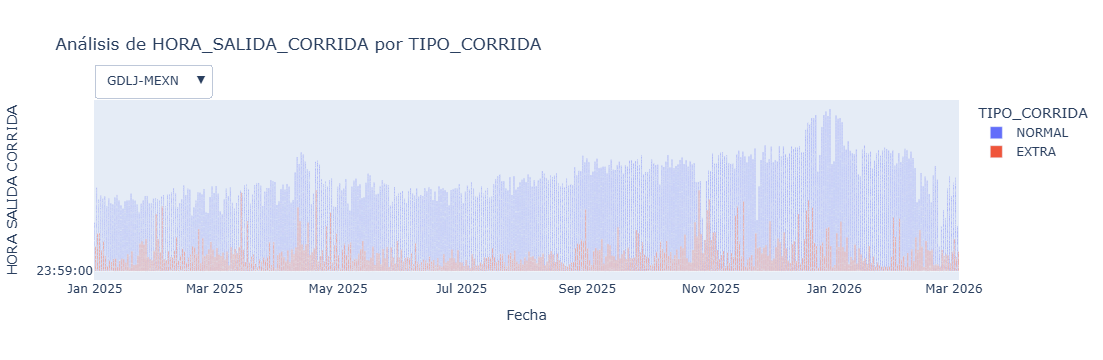

In [28]:
import pandas as pd
import plotly.express as px

def generar_grafico_interactivo(df, col_fecha, col_y, col_grupo, col_filtro, tipo_grafico='line'):
    """
    Genera un gráfico interactivo con un menú desplegable para filtrar por categorías.
    
    Parámetros:
    - df: DataFrame de pandas.
    - col_fecha: Nombre de la columna de fecha (eje X).
    - col_y: Nombre de la columna de valores (eje Y).
    - col_grupo: Nombre de la columna para la leyenda (ej. TIPO_CORRIDA).
    - col_filtro: Nombre de la columna para el menú desplegable (ej. ORIGEN_DESTINO).
    - tipo_grafico: 'line' para líneas o 'bar' para barras.
    """
    
    df_plot = df.copy()
    # Intenta convertir a fecha, si falla (porque es texto o id), lo deja como está
    try:
        # 1. Asegurar formato fecha y orden cronológico
        df_plot[col_fecha] = pd.to_datetime(df_plot[col_fecha])
        df_plot = df_plot.sort_values(col_fecha)
    except Exception:
        # Si no es fecha, al menos ordenamos los valores para que el eje X sea coherente
        df_plot = df_plot.sort_values(col_fecha)
    
    # 2. Crear gráfico inicial (usando el tipo elegido)
    if tipo_grafico == 'bar':
        fig = px.bar(df_plot, x=col_fecha, y=col_y, color=col_grupo, barmode='group')
    else:
        fig = px.line(df_plot, x=col_fecha, y=col_y, color=col_grupo)
        
    fig.update_layout(
        title=f'Análisis de {col_y} por {col_grupo}',
        xaxis_title="Fecha",
        yaxis_title=col_y.replace('_', ' ')
    )

    # 3. Configurar el menú interactivo (Dropdown)
    categorias = sorted(df_plot[col_filtro].unique())
    grupos_leyenda = df_plot[col_grupo].unique()

    buttons = []
    for cat in categorias:
        filtro_cat = df_plot[col_filtro] == cat
        
        # Preparamos los datos para cada serie de la leyenda dentro de esa categoría
        new_x = [df_plot.loc[filtro_cat & (df_plot[col_grupo] == g), col_fecha] for g in grupos_leyenda]
        new_y = [df_plot.loc[filtro_cat & (df_plot[col_grupo] == g), col_y] for g in grupos_leyenda]
        
        buttons.append(dict(
            method="restyle",
            label=str(cat),
            args=[{"x": new_x, "y": new_y}]
        ))

    fig.update_layout(
        updatemenus=[dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.0,
            y=1.2,
            xanchor="left",
            yanchor="top"
        )],
        margin=dict(t=100) # Espacio para el menú
    )

    return fig

# --- MODO DE USO ---
fig = generar_grafico_interactivo(
df=Df_2, 
col_fecha='FECHA_CORRIDA', 
col_y='HORA_SALIDA_CORRIDA', 
col_grupo='TIPO_CORRIDA', 
col_filtro='ORIGEN_DESTINO',
tipo_grafico='bar' # line o bar
 )
fig.show()


In [ ]:
Df_Horarios[Df_Horarios['ORIGEN_DESTINO']=='GDLJ-MEXN']
#Df_Horarios.to_parquet('prueba.parquet')

In [ ]:
Df1=Df.copy()
Df1['HORA_ENTERA']=Df1['HORA_SALIDA_CORRIDA'].dt.hour
Df1['HORA_SALIDA_CORRIDA']=Df1['HORA_SALIDA_CORRIDA'].dt.time

Df_Horarios = Df1.groupby(['ORIGEN_DESTINO', 'FECHA_CORRIDA', 'HORA_ENTERA']).agg({
    'CUENTA_CORRIDA': 'mean',
    'PAX_SUBEN': 'mean',
    'INGRESO_TRANSP':'mean'
}).reset_index().sort_values(by=['ORIGEN_DESTINO', 'FECHA_CORRIDA', 'PAX_SUBEN'],ascending=[True, True, False])

In [ ]:
Df_Horarios

In [29]:
import plotly.graph_objects as go
import pandas as pd

def generar_heatmap_con_selector(df):
    # 1. Preparar la lista de rutas únicas
    rutas = df['ORIGEN_DESTINO'].unique()
    fig = go.Figure()
    
    botones = []
    
    # 2. Crear un Heatmap por cada ruta
    for i, ruta in enumerate(rutas):
        df_ruta = df[df['ORIGEN_DESTINO'] == ruta]
        
        # Pivotamos los datos: Horas vs Fechas
        df_pivot = df_ruta.pivot_table(
            index='HORA_ENTERA', 
            columns='FECHA_CORRIDA', 
            values='PAX_SUBEN', 
            aggfunc='sum'
        ).fillna(0)
        
        # Añadimos el rastro (trace) al gráfico
        fig.add_trace(
            go.Heatmap(
                z=df_pivot.values,
                x=df_pivot.columns.astype(str),
                y=df_pivot.index,
                colorscale='Viridis',
                name=ruta,
                visible=(i == 0) # Solo la primera ruta es visible al inicio
            )
        )
        
        # 3. Crear la lógica del botón para esta ruta
        # 'args' le dice a Plotly qué rastros mostrar (True) y cuáles ocultar (False)
        visibilidad = [False] * len(rutas)
        visibilidad[i] = True
        
        botones.append(dict(
            label=ruta,
            method="update",
            args=[{"visible": visibilidad},
                  {"title": f"Concentración de Pasajeros: {ruta}"}]
        ))

    # 4. Configurar el menú desplegable (Layout)
    fig.update_layout(
        updatemenus=[{
            "buttons": botones,
            "direction": "down",
            "showactive": True,
            "x": 0.1,
            "xanchor": "left",
            "y": 1.15,
            "yanchor": "top"
        }],
        title=f"Concentración de Pasajeros: {rutas[0]}",
        xaxis_title="Fecha",
        yaxis_title="Hora del Día (0-23)",
        yaxis=dict(autorange="reversed", tickmode='linear')
    )

    return fig.show()

# Ejecutar
generar_heatmap_con_selector(Df_2)

KeyError: 'HORA_ENTERA'

In [ ]:
import plotly.graph_objects as go
import pandas as pd

def generar_heatmap_semanal_interactivo(df):
    # 1. Preparar los nombres de los días en orden lógico
    dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    # Si tus datos están en español, usa: ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
    
    # 2. Extraer el día de la semana de la fecha
    df_semanal = df.copy()
    df_semanal['DIA_NOMBRE'] = pd.to_datetime(df_semanal['FECHA_CORRIDA']).dt.day_name()
    
    rutas = df_semanal['ORIGEN_DESTINO'].unique()
    fig = go.Figure()
    botones = []

    for i, ruta in enumerate(rutas):
        df_ruta = df_semanal[df_semanal['ORIGEN_DESTINO'] == ruta]
        
        # Agrupamos por Día y Hora sacando el PROMEDIO de pasajeros
        # Esto nos da la "ocupación esperada" para ese momento de la semana
        df_pivot = df_ruta.pivot_table(
            index='HORA_ENTERA', 
            columns='DIA_NOMBRE', 
            values='PAX_SUBEN', 
            aggfunc='mean'
        ).reindex(columns=dias_ordenados).fillna(0)
        
        fig.add_trace(
            go.Heatmap(
                z=df_pivot.values,
                x=df_pivot.columns,
                y=df_pivot.index,
                colorscale='Viridis',
                name=ruta,
                visible=(i == 0),
                hovertemplate="Día: %{x}<br>Hora: %{y}:00<br>Promedio Pax: %{z:.2f}<extra></extra>"
            )
        )
        
        visibilidad = [False] * len(rutas)
        visibilidad[i] = True
        
        botones.append(dict(
            label=ruta,
            method="update",
            args=[{"visible": visibilidad},
                  {"title": f"Patrón Semanal de Pasajeros: {ruta}"}]
        ))

    fig.update_layout(
        updatemenus=[{
            "buttons": botones,
            "direction": "down",
            "showactive": True,
            "x": 0, "y": 1.2
        }],
        title=f"Patrón Semanal de Pasajeros: {rutas[0]}",
        xaxis_title="Día de la Semana",
        yaxis_title="Hora del Día",
        yaxis=dict(autorange="reversed", tickmode='linear', dtick=1)
    )

    return fig.show()

# Ejecutar con tu DataFrame original o el Df_Horarios
generar_heatmap_semanal_interactivo(Df_Horarios)

In [ ]:
import plotly.graph_objects as go
import pandas as pd

def generar_analisis_completo(df_horarios):
    # 1. Preparación de fechas y días
    df = df_horarios.copy()
    df['FECHA_CORRIDA'] = pd.to_datetime(df['FECHA_CORRIDA'])
    df['DIA_NOMBRE'] = df['FECHA_CORRIDA'].dt.day_name()
    
    # Asegurar orden de días (puedes cambiarlos a español si prefieres)
    dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    rutas = df['ORIGEN_DESTINO'].unique()
    metricas = ['PAX_SUBEN', 'CUENTA_CORRIDA', 'INGRESO_TRANSP']
    nombres_metricas = {
        'PAX_SUBEN': 'Promedio Pasajeros', 
        'CUENTA_CORRIDA': 'Frecuencia Corridas',
        'INGRESO_TRANSP': 'Ingreso Promedio'
    }

    fig = go.Figure()

    # 2. Generar todos los rastros (traces)
    for ruta in rutas:
        for metrica in metricas:
            df_ruta = df[df['ORIGEN_DESTINO'] == ruta]
            
            df_pivot = df_ruta.pivot_table(
                index='HORA_ENTERA',
                columns='DIA_NOMBRE',
                values=metrica,
                aggfunc='mean'
            ).reindex(columns=dias_orden).fillna(0)

            fig.add_trace(go.Heatmap(
                z=df_pivot.values,
                x=df_pivot.columns,
                y=df_pivot.index,
                colorscale='Viridis' if metrica == 'PAX_SUBEN' else 'Magma' if metrica == 'CUENTA_CORRIDA' else 'Cividis',
                name=f"{ruta} - {metrica}",
                visible=False,
                hovertemplate=f"Día: %{{x}}<br>Hora: %{{y}}:00<br>{nombres_metricas[metrica]}: %{{z:.2f}}<extra></extra>"
            ))

    # Primer rastro visible
    fig.data[0].visible = True

    # 3. Lógica de visibilidad (Cruzar Rutas x Métricas)
    def get_visibility(target_ruta, target_metrica):
        v = []
        for r in rutas:
            for m in metricas:
                v.append(r == target_ruta and m == target_metrica)
        return v

    # Botones de Ruta (cambian la ruta pero mantienen la métrica actual como 'PAX_SUBEN')
    botones_ruta = [
        dict(label=r, method="update", 
             args=[{"visible": get_visibility(r, 'PAX_SUBEN')}, 
                   {"title": f"Análisis: {r} (Mostrando {nombres_metricas['PAX_SUBEN']})"}]
            ) for r in rutas
    ]

    # Botones de Métrica (Afectan a la primera ruta por defecto al cambiar)
    botones_metrica = [
        dict(label=nombres_metricas[m], method="update", 
             args=[{"visible": get_visibility(rutas[0], m)},
                   {"title": f"Análisis: {rutas[0]} (Mostrando {nombres_metricas[m]})"}]
            ) for m in metricas
    ]

    # 4. Layout con Anotaciones en lugar de Headers
    fig.update_layout(
        updatemenus=[
            {"buttons": botones_ruta, "direction": "down", "x": 0.0, "y": 1.2, "showactive": True},
            {"buttons": botones_metrica, "direction": "down", "x": 0.3, "y": 1.2, "showactive": True}
        ],
        annotations=[
            dict(text="Seleccionar Ruta:", x=0.0, y=1.28, xref="paper", yref="paper", showarrow=False, font=dict(size=13, shadow="black")),
            dict(text="Seleccionar Métrica:", x=0.3, y=1.28, xref="paper", yref="paper", showarrow=False, font=dict(size=13))
        ],
        title=f"Análisis Operativo: {rutas[0]}",
        xaxis_title="Día de la Semana",
        yaxis_title="Hora del Día",
        yaxis=dict(autorange="reversed", tickmode='linear', dtick=1),
        margin=dict(t=150) # Espacio para los menús
    )

    return fig.show()

# Ejecutar
generar_analisis_completo(Df_Horarios)

In [ ]:
#Df_Horarios.to_parquet('prueba.parquet')